# MinneApple — Apple detection annotations through the author's data loader (arXiv:1909.06441v2)

**Paper**: Nicolai Häni, Pravakar Roy, Volkan Isler, *MinneApple: A Benchmark Dataset for Apple
Detection and Segmentation*, arXiv:1909.06441v2 — https://arxiv.org/abs/1909.06441

**Author code**: https://github.com/nicolaihaeni/MinneApple (MIT), pinned commit
`86ec54b7a3b0aa79f4f60a86ec3f2e2372260c98` — file `data/apple_dataset.py`, the dataset class used verbatim by the authors'
`train_rcnn.py` / `predict_rcnn.py` (`AppleDataset(os.path.join(args.data_path, 'train'), ...)`).

**Dataset**: UMN DRUM record [doi:10.13020/8ecp-3r13](https://doi.org/10.13020/8ecp-3r13)
(handle [11299/206575](https://conservancy.umn.edu/handle/11299/206575)), file `detection.tar.gz`
(1,825,397,590 bytes, MD5-verified below).

## Scope of this notebook (partial demonstration)

The released detection archive already contains the authors' converted annotation format —
`detection/train/images/*.png` paired with `detection/train/masks/*.png` where each mask pixel
value is one apple instance (0 = background) — exactly what the repository's
`scripts/json_to_masks.py` produces from the raw VGG-annotator JSON (the raw JSON itself is not
part of the public archive). This notebook reproduces the paper's detection annotation pipeline on
**one training image**: load it with the author's `AppleDataset` (verbatim), which decodes the
per-instance masks and derives bounding boxes on the fly, then visualize the reference masks and
reference boxes and export a small per-instance table.

**It does not** train or run any detector: no pretrained baseline weights were published for this
paper (and test-set labels are withheld; evaluation is via CodaLab). This single-example run does
**not** verify the paper's dataset-level benchmark numbers.

**実行範囲(日本語)**: 公開アーカイブは既に変換済みの形式(`detection/train/{images,masks}/*.png`,
マスクの画素値=インスタンス番号, 0=背景)で配布されています。本ノートブックは作者の
`AppleDataset`(逐語複製)で 1 枚の学習画像を読み込み、インスタンスマスクの復元とバウンディング
ボックスのオンザフライ抽出を再現して可視化します。学習済み重みは公開されていないため、検出器の
推論・学習は行いません。単一例の実行は論文のデータセット規模の結果を検証するものではありません。

**Runtime**: a standard **CPU** runtime is sufficient — pure numpy/Pillow/torch data handling,
no model inference. **ランタイム**: 標準 CPU で十分です(モデル推論なし)。

**Expected duration**: ~5–10 minutes; the single large download is `detection.tar.gz` (1.83 GB).
所要時間の目安: 全体で 5–10 分、主な時間は 1.83 GB のダウンロードです。

**Execution status / 実行状態**: this notebook was executed end-to-end on a fresh Colab CPU
runtime; the outputs below are from that run.

**Source code provenance / ソースコードの出所**: the `AppleDataset` class below is copied
**verbatim** from `data/apple_dataset.py` at commit `86ec54b7a3b0aa79f4f60a86ec3f2e2372260c98` (only its module-level `import`
lines were moved into the importing cells). This is an AI-assisted notebook: the authors did not
provide it. The executed example and listed checks were validated, but untested behavior is not
guaranteed.
(本ノートブックは AI 補助により作成されました。作者のクラスは逐語複製しています。)

## 1. Environment check / 環境確認

The loader imports `torch` and uses `numpy`/`Pillow`; visualization uses `matplotlib`. All are
preinstalled on Colab — we print the observed versions and fail loudly if anything required is
missing (no hidden installs). **期待結果**: 各パッケージのバージョンが表示されます。

In [ ]:
import numpy as np
import PIL, torch, matplotlib
import matplotlib.pyplot as plt

print("torch", torch.__version__)
print("numpy", np.__version__)
print("Pillow", PIL.__version__)
print("matplotlib", matplotlib.__version__)
assert torch.as_tensor is not None and np.asarray is not None

torch 2.11.0+cpu
numpy 2.1.3
Pillow 11.3.0
matplotlib 3.10.0


## 2. Dataset download (Colab-only) / データセットのダウンロード

We download **only** `detection.tar.gz` from the DRUM item `11299/206575` (DSpace REST bitstream
endpoint; public, no credentials) and verify its recorded **MD5
`d24a2f70144f1a3c5a52ffef66c50630`** and size before use. All dataset bytes stay on the Colab VM
under `/content`. The other archive members (`counting.tar.gz`, `test_data.zip`) are not needed
for this demonstration. **期待結果**: 進行状況表示の後、`MD5 OK` と表示されます。不一致なら例外で停止します。

In [ ]:
import hashlib, requests
from pathlib import Path

URL = "https://conservancy.umn.edu/server/api/core/bitstreams/3ef26f04-6467-469b-9857-f443ffa1bb61/content"
EXPECTED_MD5 = "d24a2f70144f1a3c5a52ffef66c50630"
EXPECTED_SIZE = 1_825_397_590
tar_path = Path("/content/detection.tar.gz")

if not tar_path.exists():
    with requests.get(URL, stream=True, timeout=(30, 120)) as r:
        r.raise_for_status()
        done = 0
        with open(tar_path, "wb") as f:
            for chunk in r.iter_content(chunk_size=8 << 20):
                f.write(chunk)
                done += len(chunk)
                if done // (200 << 20) != (done - len(chunk)) // (200 << 20):
                    print(f"downloaded {done/1e6:.0f} MB", flush=True)
else:
    print("reusing already-downloaded archive")

size = tar_path.stat().st_size
print(f"size on disk: {size} bytes (expected {EXPECTED_SIZE})")
assert size == EXPECTED_SIZE, "unexpected archive size"

h = hashlib.md5()
with open(tar_path, "rb") as f:
    for chunk in iter(lambda: f.read(16 << 20), b""):
        h.update(chunk)
print("md5:", h.hexdigest())
assert h.hexdigest() == EXPECTED_MD5, "MD5 mismatch — do not use this archive"
print("MD5 OK")

downloaded 210 MB


downloaded 419 MB


downloaded 629 MB


downloaded 839 MB


downloaded 1049 MB


downloaded 1258 MB


downloaded 1468 MB


downloaded 1678 MB


size on disk: 1825397590 bytes (expected 1825397590)


md5: d24a2f70144f1a3c5a52ffef66c50630
MD5 OK


## 3. Inspect the archive structure (in Colab) / アーカイブ構造の確認

The internal layout is verified **here**, not assumed: one streaming pass over the tar records
member names (no extraction) so we can confirm the converted detection layout
(`detection/train/images` + `detection/train/masks` + `detection/test/images`) and the paper's
counts (670 annotated train images; 331 unlabeled test images). **期待結果**: train 画像 670・
train マスク 670・test 画像 331(マスクなし)という集計が表示されます。

In [ ]:
import tarfile
from collections import Counter

counts = Counter()
first_names = {}
with tarfile.open(tar_path, "r:gz") as tf:
    for m in tf:
        if not m.isfile():
            continue
        parts = m.name.split("/")
        if len(parts) >= 4 and parts[0] == "detection":
            split, kind = parts[1], parts[2]
            counts[(split, kind)] += 1
            first_names.setdefault((split, kind), m.name)
        else:
            counts[("other", "other")] += 1

for k in sorted(counts):
    print(k, counts[k], "| e.g.", first_names[k])
train_imgs = counts[("train", "images")]
train_masks = counts[("train", "masks")]
assert train_imgs == train_masks, "every train image must have a mask"
assert counts[("test", "masks")] == 0, "test masks are withheld (paper Section IV)"


('test', 'images') 331 | e.g. detection/test/images/dataset2_back_630.png
('train', 'images') 670 | e.g. detection/train/images/20150919_174730_image161.png
('train', 'masks') 670 | e.g. detection/train/masks/20150919_174151_image11.png


## 4. Select one deterministic sample / サンプル選択(決定的)

We pick the **alphabetically first** train image that has a paired mask — a deterministic,
reproducible choice (not cherry-picked by appearance). **期待結果**: 選ばれた画像名とマスク名が
表示されます。

In [ ]:
train_image_bases, train_mask_bases = set(), set()
with tarfile.open(tar_path, "r:gz") as tf:
    for m in tf:
        if not m.isfile():
            continue
        parts = m.name.split("/")
        if len(parts) == 4 and parts[0] == "detection" and parts[1] == "train":
            if parts[2] == "images" and parts[3].endswith(".png"):
                train_image_bases.add(parts[3])
            elif parts[2] == "masks" and parts[3].endswith(".png"):
                train_mask_bases.add(parts[3])

paired = sorted(train_image_bases & train_mask_bases)
assert paired, "no train image with a paired mask found"
sample_base = paired[0]
print(f"{len(train_image_bases)} train images, {len(train_mask_bases)} train masks, "
      f"{len(paired)} paired basenames")
print("selected sample (alphabetically first paired):", sample_base)

670 train images, 670 train masks, 670 paired basenames
selected sample (alphabetically first paired): 20150919_174151_image1.png


## 5. Extract only the selected pair into the loader's expected layout / 必要な 2 ファイルだけ展開

`AppleDataset(root_dir, ...)` expects `root_dir/images` and `root_dir/masks` with aligned sorted
filenames. We extract the selected image and its mask into `/content/minneapple_subset/train/...`
(a second streaming pass; only two files are written). **期待結果**: 展開された 2 ファイルの
サイズが表示されます。

In [ ]:
import tarfile
from pathlib import Path

subset_dir = Path("/content/minneapple_subset/train")
(subset_dir / "images").mkdir(parents=True, exist_ok=True)
(subset_dir / "masks").mkdir(parents=True, exist_ok=True)

image_member = f"detection/train/images/{sample_base}"
mask_member = f"detection/train/masks/{sample_base}"
want = {image_member, mask_member}

found = set()
with tarfile.open(tar_path, "r:gz") as tf:
    for m in tf:
        if m.isfile() and m.name in want and m.name not in found:
            dest = subset_dir / "images" / sample_base if m.name == image_member \
                else subset_dir / "masks" / sample_base
            dest.write_bytes(tf.extractfile(m).read())
            found.add(m.name)
            if len(found) == 2:
                break
assert found == want, f"members not found: {want - found}"

for p in sorted(subset_dir.glob("*/*.png")):
    print(f"{p.relative_to(subset_dir)}  {p.stat().st_size} bytes")

images/20150919_174151_image1.png  2027042 bytes
masks/20150919_174151_image1.png  15242 bytes


## 6. Validate the extracted bytes / 抽出ファイルの検証

Before scientific use: the image must decode (PIL) and the mask must decode as `uint8` whose
instance ids are exactly `0..N` (0 = background, as the author conversion defines). We also check
that mask and image dimensions agree — the paper (Table I) states 1280 × 720 detection images.
**期待結果**: 画像とマスクの寸法・インスタンス数が表示されます。

In [ ]:
import numpy as np
from PIL import Image

img_pil = Image.open(subset_dir / "images" / sample_base)
img_pil.load()
print("image:", img_pil.size, img_pil.mode)

mask_pil = Image.open(subset_dir / "masks" / sample_base)
mask_pil.load()
mask = np.array(mask_pil)
print("mask:", mask.shape, mask.dtype)
ids = np.unique(mask)
print("instance ids:", ids)
assert ids[0] == 0 and ids[-1] == len(ids) - 1, "ids must be 0..N (0 = background)"
assert mask.shape == img_pil.size[::-1], "mask/image dimension mismatch"
n_instances = len(ids) - 1
print("instances in mask:", n_instances)

image: (720, 1280) RGB
mask: (1280, 720) uint8
instance ids: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95]
instances in mask: 95


## 7. Input preview / 入力画像のプレビュー

The sample orchard image exactly as released (no processing); its member path inside
`detection.tar.gz` is printed above. **期待結果**: 果樹園写真が表示されます。

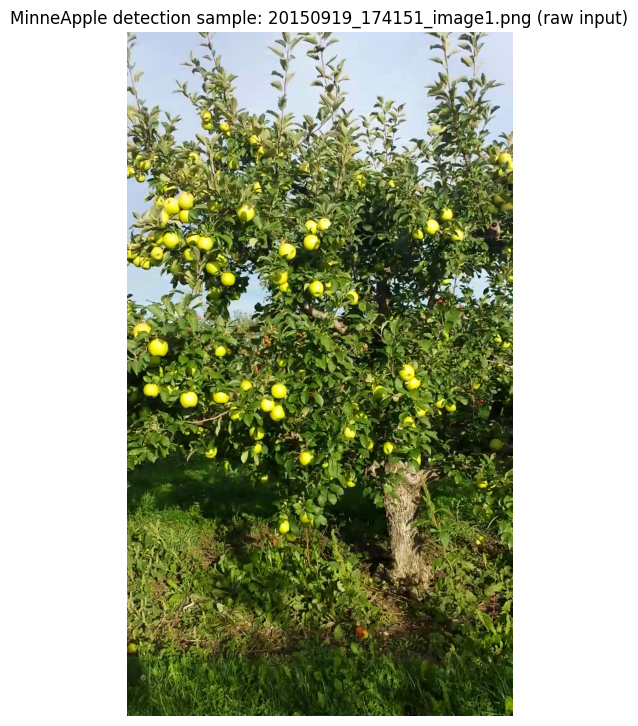

In [ ]:
w_px, h_px = img_pil.size
plt.figure(figsize=(5, 5 * h_px / w_px))
plt.imshow(img_pil)
plt.title(f"MinneApple detection sample: {sample_base} (raw input)")
plt.axis("off")
plt.show()

## 8. Author loader `AppleDataset` (verbatim) / 作者のデータローダ

The class below is copied **verbatim** from `data/apple_dataset.py` at commit `86ec54b7a3b0aa79f4f60a86ec3f2e2372260c98`
(only its module imports moved above): it lists `images/` and `masks/` in sorted order, splits the
color-encoded mask into per-instance binary masks via `mask == obj_ids[:, None, None]`, derives
each bounding box from `np.where` on the binary mask (skipping degenerate boxes), and returns the
torch `target` dict (`boxes`, `labels` — all 1 for the single apple class, `masks`, `image_id`,
`area`, `iscrowd`). **期待結果**: クラス定義が実行されます(出力なし)。

In [ ]:
#####################################
# Class that takes the input instance masks
# and extracts bounding boxes on the fly
#####################################
class AppleDataset(object):
    def __init__(self, root_dir, transforms):
        self.root_dir = root_dir
        self.transforms = transforms

        # Load all image and mask files, sorting them to ensure they are aligned
        self.imgs = list(sorted(os.listdir(os.path.join(root_dir, "images"))))
        self.masks = list(sorted(os.listdir(os.path.join(root_dir, "masks"))))

    def __getitem__(self, idx):
        # Load images and masks
        img_path = os.path.join(self.root_dir, "images", self.imgs[idx])
        mask_path = os.path.join(self.root_dir, "masks", self.masks[idx])

        img = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path)     # Each color of mask corresponds to a different instance with 0 being the background

        # Convert the PIL image to np array
        mask = np.array(mask)
        obj_ids = np.unique(mask)

        # Remove background id
        obj_ids = obj_ids[1:]

        # Split the color-encoded masks into a set of binary masks
        masks = mask == obj_ids[:, None, None]

        # Get bbox coordinates for each mask
        num_objs = len(obj_ids)
        boxes = []
        h, w = mask.shape
        for ii in range(num_objs):
            pos = np.where(masks[ii])
            xmin = np.min(pos[1])
            xmax = np.max(pos[1])
            ymin = np.min(pos[0])
            ymax = np.max(pos[0])

            if xmin == xmax or ymin == ymax:
                continue

            xmin = np.clip(xmin, a_min=0, a_max=w)
            xmax = np.clip(xmax, a_min=0, a_max=w)
            ymin = np.clip(ymin, a_min=0, a_max=h)
            ymax = np.clip(ymax, a_min=0, a_max=h)
            boxes.append([xmin, ymin, xmax, ymax])

        # Convert everything into a torch.Tensor
        boxes = torch.as_tensor(boxes, dtype=torch.float32)

        # There is only one class (apples)
        labels = torch.ones((num_objs,), dtype=torch.int64)
        masks = torch.as_tensor(masks, dtype=torch.uint8)

        image_id = torch.tensor([idx])
        area = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0])

        # All instances are not crowd
        iscrowd = torch.zeros((num_objs,), dtype=torch.int64)

        target = {}
        target["boxes"] = boxes
        target["labels"] = labels
        target["masks"] = masks
        target["image_id"] = image_id
        target["area"] = area
        target["iscrowd"] = iscrowd

        if self.transforms is not None:
            img, target = self.transforms(img, target)

        return img, target

    def __len__(self):
        return len(self.imgs)

    def get_img_name(self, idx):
        return self.imgs[idx]


We instantiate the author loader on the converted subset and load item 0 — this is the exact
loading path `train_rcnn.py` uses (`AppleDataset(os.path.join(args.data_path, 'train'), ...)`),
so the root is the `train` split directory. **期待結果**: `boxes/masks` の形状と `labels`
(すべて 1 = apple)が表示されます。

In [ ]:
import os

ds = AppleDataset(str(subset_dir), transforms=None)
print("dataset length:", len(ds), "| first image:", ds.get_img_name(0))
img_loaded, target = ds[0]

print("PIL image:", img_loaded.size, img_loaded.mode)
print("boxes:", tuple(target["boxes"].shape), target["boxes"].dtype)
print("masks:", tuple(target["masks"].shape), target["masks"].dtype)
print("labels:", target["labels"].tolist())
print("iscrowd:", target["iscrowd"].tolist())
print("image_id:", target["image_id"].tolist(), "| areas(px^2):", target["area"].tolist())

dataset length: 1 | first image: 20150919_174151_image1.png


PIL image: (720, 1280) RGB
boxes: (95, 4) torch.float32
masks: (95, 1280, 720) torch.uint8
labels: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
iscrowd: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
image_id: [0] | areas(px^2): [575.0, 437.0, 360.0, 110.0, 550.0, 108.0, 918.0, 420.0, 360.0, 441.0, 238.0, 480.0, 252.0, 1015.0, 1054.0, 546.0, 910.0, 1110.0, 957.0, 780.0, 520.0, 352.0, 594.0, 525.0, 1368.0, 616.0, 720.0, 520.0, 700.0, 702.0, 1044.0, 1558.0, 650.0, 754.0, 928.0, 928.0, 841.0, 567.0, 990.0, 1188.0, 102

## 9. Visualization: reference annotations over the input / 参照アノテーションの重畳表示

The masks/boxes here are **reference annotations released by the authors** (not model
predictions): each colored region is one polygon drawn by the authors' conversion into the released
mask PNG, and each box is the author loader's on-the-fly bbox. This is the supervision a detector
would be trained against in the paper's detection task. **期待結果**: 入力画像に参照マスク
(半透明)と参照枠を重畳した 3 パネル図が表示されます。

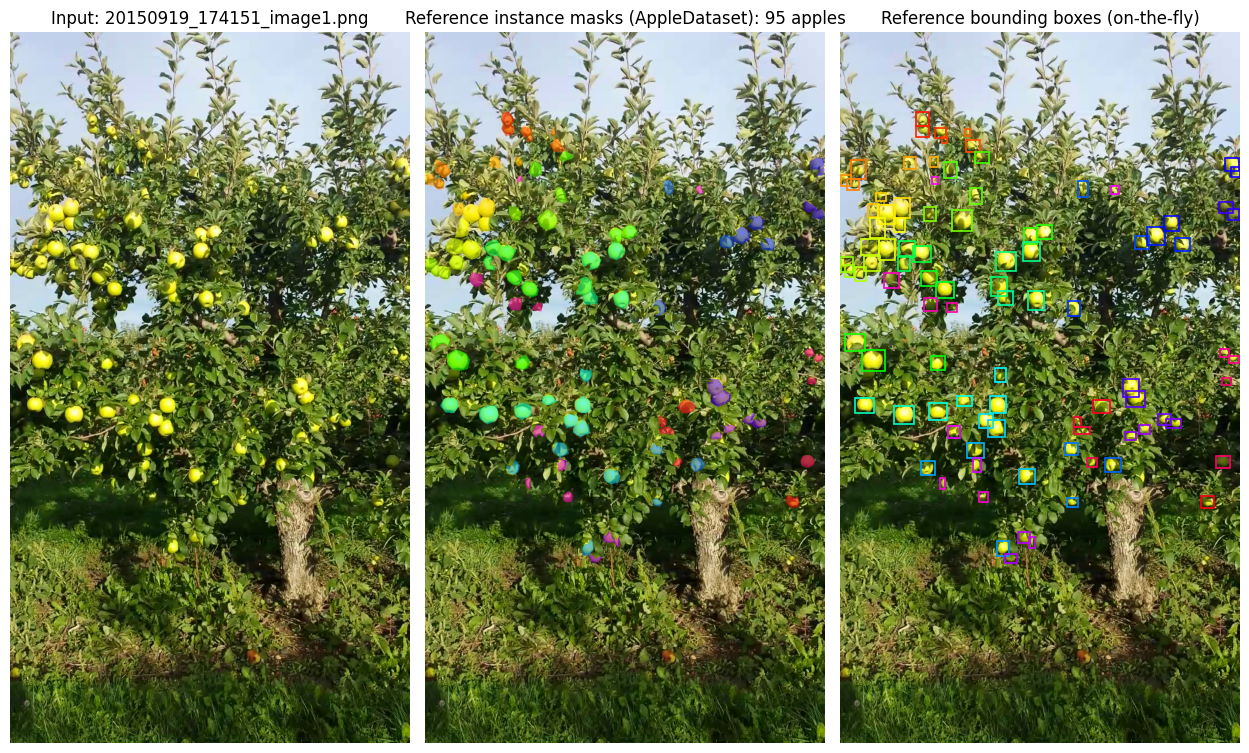

In [ ]:
rgb = np.array(img_loaded)
n = len(target["boxes"])
colors = plt.get_cmap("hsv", n + 1)

overlay = rgb.copy()
for i in range(n):
    m = target["masks"][i].numpy().astype(bool)
    color = (np.array(colors(i + 1)[:3]) * 255).astype(np.uint8)
    overlay[m] = (0.55 * color + 0.45 * overlay[m]).astype(np.uint8)

h_px, w_px = rgb.shape[:2]
fig, ax = plt.subplots(1, 3, figsize=(12.6, 4.2 * h_px / w_px))
ax[0].imshow(rgb)
ax[0].set_title(f"Input: {ds.get_img_name(0)}")
ax[1].imshow(overlay)
ax[1].set_title(f"Reference instance masks (AppleDataset): {n} apples")
ax[2].imshow(rgb)
for i, (x1, y1, x2, y2) in enumerate(target["boxes"].tolist()):
    ax[2].add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False,
                                  edgecolor=colors(i + 1), linewidth=1.2))
ax[2].set_title("Reference bounding boxes (on-the-fly)")
for a in ax:
    a.axis("off")
plt.tight_layout()
plt.savefig("/content/minneapple_overlay.png", dpi=110, bbox_inches="tight")
plt.show()

## 10. Per-instance table and CSV export / インスタンス表と CSV 出力

A small quantitative record of the single example: the author-defined `area` (box area in px²)
and the mask pixel count per instance, with a CSV written inside Colab.
**期待結果**: インスタンスごとの表と `minneapple_instances.csv` への書き出し。

In [ ]:
import csv

rows = []
for i, (box, area) in enumerate(zip(target["boxes"].tolist(), target["area"].tolist())):
    x1, y1, x2, y2 = box
    rows.append({"instance": i, "xmin": x1, "ymin": y1, "xmax": x2, "ymax": y2,
                 "box_area_px2": area, "mask_pixels": int(target["masks"][i].sum())})

csv_path = Path("/content/minneapple_instances.csv")
with open(csv_path, "w", newline="") as f:
    w = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
    w.writeheader()
    w.writerows(rows)

print(f"{len(rows)} instances; CSV -> {csv_path}")
for r in rows[:20]:
    print(r)
if len(rows) > 20:
    print(f"... {len(rows) - 20} more rows in the CSV")

95 instances; CSV -> /content/minneapple_instances.csv
{'instance': 0, 'xmin': 137.0, 'ymin': 144.0, 'xmax': 160.0, 'ymax': 169.0, 'box_area_px2': 575.0, 'mask_pixels': 445}
{'instance': 1, 'xmin': 137.0, 'ymin': 169.0, 'xmax': 160.0, 'ymax': 188.0, 'box_area_px2': 437.0, 'mask_pixels': 363}
{'instance': 2, 'xmin': 171.0, 'ymin': 172.0, 'xmax': 191.0, 'ymax': 190.0, 'box_area_px2': 360.0, 'mask_pixels': 294}
{'instance': 3, 'xmin': 183.0, 'ymin': 188.0, 'xmax': 193.0, 'ymax': 199.0, 'box_area_px2': 110.0, 'mask_pixels': 90}
{'instance': 4, 'xmin': 226.0, 'ymin': 194.0, 'xmax': 251.0, 'ymax': 216.0, 'box_area_px2': 550.0, 'mask_pixels': 391}
{'instance': 5, 'xmin': 225.0, 'ymin': 175.0, 'xmax': 234.0, 'ymax': 187.0, 'box_area_px2': 108.0, 'mask_pixels': 70}
{'instance': 6, 'xmin': 19.0, 'ymin': 230.0, 'xmax': 46.0, 'ymax': 264.0, 'box_area_px2': 918.0, 'mask_pixels': 595}
{'instance': 7, 'xmin': 13.0, 'ymin': 264.0, 'xmax': 34.0, 'ymax': 284.0, 'box_area_px2': 420.0, 'mask_pixels': 312}

## 11. Interpretation, limitations, references / 解釈・限界・参照

**What was reproduced**: the paper's released detection annotations for one training image,
processed exactly as the authors' pipeline does — per-instance indexed mask PNG (the released form
of the VGG-polygon annotations) → binary instance masks and on-the-fly bounding boxes via the
author's `AppleDataset` at pinned commit `86ec54b7a3b0aa79f4f60a86ec3f2e2372260c98`. The instance count printed above is a direct
observation of this single sample.

**What was NOT reproduced / 本ノートブックで検証しないこと**:
- No detector is trained or run: the authors published **no trained weights** (prior investigation
  blocker). Their reported AP 0.438 (Faster R-CNN, ResNet-50) is a dataset-level result over 670
  train / 331 test images with withheld test labels — out of scope here.
- The raw VGG-annotator JSON is not part of the public archive, so the repository's
  `scripts/json_to_masks.py` conversion could not be re-run on released data; the released masks
  are its output format.
- Segmentation UNet (IoU 0.685), patch counting, and yield estimation (95.5–97.8%) are likewise
  not exercised; this single-example run makes no claim about the paper's benchmark numbers.

**Validation record**: executed end-to-end on a fresh Colab **CPU** runtime (saved outputs below);
archive size + MD5 verified before use; author class is verbatim from pinned commit `86ec54b7a3b0aa79f4f60a86ec3f2e2372260c98`.

**References**: paper https://arxiv.org/abs/1909.06441 · code
https://github.com/nicolaihaeni/MinneApple (MIT) · dataset
https://conservancy.umn.edu/handle/11299/206575 (doi:10.13020/8ecp-3r13).
If you use MinneApple, please cite the authors (bibtex in the repository README).